In [20]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt

In [21]:
data = pd.read_csv("hospital_readmissions.csv")

print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())


Dataset Shape: (25000, 17)

First 5 rows:
       age  time_in_hospital  n_lab_procedures  n_procedures  n_medications  \
0  [70-80)                 8                72             1             18   
1  [70-80)                 3                34             2             13   
2  [50-60)                 5                45             0             18   
3  [70-80)                 2                36             0             12   
4  [60-70)                 1                42             0              7   

   n_outpatient  n_inpatient  n_emergency medical_specialty       diag_1  \
0             2            0            0           Missing  Circulatory   
1             0            0            0             Other        Other   
2             0            0            0           Missing  Circulatory   
3             1            0            0           Missing  Circulatory   
4             0            0            0  InternalMedicine        Other   

        diag_2       diag_

In [22]:
print("\nMissing Values:")
print(data.isnull().sum())



Missing Values:
age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64


In [23]:
data["readmitted"] = data["readmitted"].map({
    "no": 0,
    "yes": 1
})

In [24]:
categorical_columns = data.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(data[column])

In [25]:
X = data.drop("readmitted", axis=1)
y = data["readmitted"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
model_l2 = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000
)

model_l2.fit(X_train, y_train)

y_pred_l2 = model_l2.predict(X_test)
y_prob_l2 = model_l2.predict_proba(X_test)[:, 1]



model_no_l2 = LogisticRegression(
    penalty=None,
    max_iter=1000
)

model_no_l2.fit(X_train, y_train)

y_pred_no_l2 = model_no_l2.predict(X_test)
y_prob_no_l2 = model_no_l2.predict_proba(X_test)[:, 1]

In [37]:
accuracy_l2 = accuracy_score(y_test, y_pred_l2)
precision_l2 = precision_score(y_test, y_pred_l2)
recall_l2 = recall_score(y_test, y_pred_l2)
roc_auc_l2 = roc_auc_score(y_test, y_prob_l2)


accuracy_no_l2 = accuracy_score(y_test, y_pred_no_l2)
precision_no_l2 = precision_score(y_test, y_pred_no_l2)
recall_no_l2 = recall_score(y_test, y_pred_no_l2)
roc_auc_no_l2 = roc_auc_score(y_test, y_prob_no_l2)


print("\n========== MODEL COMPARISON ==========")

print("\nWith L2 Regularization:")
print("Accuracy :", round(accuracy_l2, 4))
print("Precision:", round(precision_l2, 4))
print("Recall   :", round(recall_l2, 4))
print("ROC-AUC  :", round(roc_auc_l2, 4))


print("\nWithout L2 Regularization:")
print("Accuracy :", round(accuracy_no_l2, 4))
print("Precision:", round(precision_no_l2, 4))
print("Recall   :", round(recall_no_l2, 4))
print("ROC-AUC  :", round(roc_auc_no_l2, 4))


========== MODEL COMPARISON ==========

With L2 Regularization:
Accuracy : 0.6068
Precision: 0.6295
Recall   : 0.3981
ROC-AUC  : 0.6459

Without L2 Regularization:
Accuracy : 0.6068
Precision: 0.6295
Recall   : 0.3981
ROC-AUC  : 0.6459


In [31]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_l2))


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.79      0.68      2649
           1       0.63      0.40      0.49      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.58      5000
weighted avg       0.61      0.61      0.59      5000



In [38]:

# Confusion Matrix - With L2

cm_l2 = confusion_matrix(y_test, y_pred_l2)

print("\nConfusion Matrix - With L2:")
print(cm_l2)

tn, fp, fn, tp = cm_l2.ravel()

print("\nTrue Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)


Confusion Matrix - With L2:
[[2098  551]
 [1415  936]]

True Negative : 2098
False Positive: 551
False Negative: 1415
True Positive : 936


In [39]:
# Confusion Matrix - Without L2

cm_no_l2 = confusion_matrix(y_test, y_pred_no_l2)

print("\nConfusion Matrix - Without L2:")
print(cm_no_l2)

tn, fp, fn, tp = cm_no_l2.ravel()

print("\nTrue Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)


Confusion Matrix - Without L2:
[[2098  551]
 [1415  936]]

True Negative : 2098
False Positive: 551
False Negative: 1415
True Positive : 936


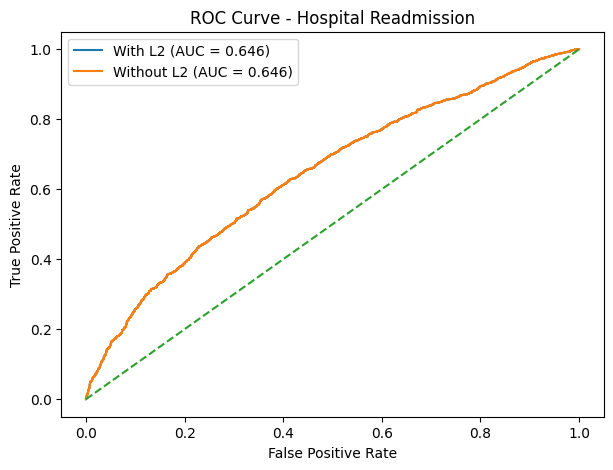

In [40]:
# ROC Curve for both models

fpr_l2, tpr_l2, _ = roc_curve(y_test, y_prob_l2)
fpr_no_l2, tpr_no_l2, _ = roc_curve(y_test, y_prob_no_l2)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_l2,
    tpr_l2,
    label="With L2 (AUC = {:.3f})".format(roc_auc_l2)
)

plt.plot(
    fpr_no_l2,
    tpr_no_l2,
    label="Without L2 (AUC = {:.3f})".format(roc_auc_no_l2)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Hospital Readmission")

plt.legend()
plt.show()

In [43]:
# ==============================
# CLINICAL COST
# ==============================

print("\n========== CLINICAL COST ==========")

# With L2
cm_l2 = confusion_matrix(y_test, y_pred_l2)
tn_l2, fp_l2, fn_l2, tp_l2 = cm_l2.ravel()

print("\n--- With L2 Regularization ---")

print("False Negatives:", fn_l2)
print("False Positives:", fp_l2)

print("\nFalse Negative:")
print("Patient is actually readmitted but model predicts NOT readmitted.")

print("\nFalse Positive:")
print("Model predicts readmission but patient is NOT readmitted.")


# Without L2
cm_no_l2 = confusion_matrix(y_test, y_pred_no_l2)
tn_no_l2, fp_no_l2, fn_no_l2, tp_no_l2 = cm_no_l2.ravel()

print("\n--- Without Regularization ---")

print("False Negatives:", fn_no_l2)
print("False Positives:", fp_no_l2)

print("\nFalse Negative:")
print("Patient is actually readmitted but model predicts NOT readmitted.")

print("\nFalse Positive:")
print("Model predicts readmission but patient is NOT readmitted.")


print("\nIn this case, False Negatives can be more clinically")
print("important because a high-risk patient may not receive")
print("additional monitoring or follow-up.")


========== CLINICAL COST ==========

--- With L2 Regularization ---
False Negatives: 1415
False Positives: 551

False Negative:
Patient is actually readmitted but model predicts NOT readmitted.

False Positive:
Model predicts readmission but patient is NOT readmitted.

--- Without Regularization ---
False Negatives: 1415
False Positives: 551

False Negative:
Patient is actually readmitted but model predicts NOT readmitted.

False Positive:
Model predicts readmission but patient is NOT readmitted.

In this case, False Negatives can be more clinically
important because a high-risk patient may not receive
additional monitoring or follow-up.
